In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
import datetime
import matplotlib.pyplot as plt

In [2]:
DATA_FOLDER = Path(os.path.abspath("")).parent.parent / "taxi_data" / "yellow_tripdata"
GENERIC_FILENAME = "yellow_tripdata_taxi_data_"

## Create a sorted dict with file dates

In [3]:
data_filenames = os.listdir(DATA_FOLDER)
filenames_dict = {"_".join(filename.split(".")[0].split("_")[4:]): filename for filename in data_filenames}

date_dict = {datetime.datetime(int(x.split("_")[0]), int(x.split("_")[1]), 1): x for x in list(filenames_dict.keys())}
sorted_date_dict = dict(sorted(date_dict.items(), key=lambda x: x[0]))

print(len(data_filenames))
COUNTER = len(data_filenames)

29


# EXECUTE BELOW TO LOAD ALL PARQUET FILES

In [21]:
df_main = pd.DataFrame()
for date in sorted_date_dict.values():
    filename = "".join([GENERIC_FILENAME, date, ".parquet"])
    filepath = Path.joinpath(DATA_FOLDER, filename)
    df = pd.read_parquet(filepath, dtype_backend="pyarrow")

    df_main = pd.concat([df_main, df])

# *****************************

# EXECUTE BELOW FOR ONLY THE LATEST FILE

In [4]:
df_main = pd.DataFrame()
filename = "".join([GENERIC_FILENAME, str(list(sorted_date_dict.values())[-1]), ".parquet"])
filepath = Path.joinpath(DATA_FOLDER, filename)
df_main = pd.read_parquet(filepath, dtype_backend="pyarrow")

# *****************************

In [5]:
# sanity check
print(df_main.shape)
print(df_main.memory_usage(deep=True).sum() / 1024 ** 2, "MiB")

(4090836, 20)
589.8897943496704 MiB


In [27]:
invalid_distance = df_main["trip_distance"] == 0
invalid_passenger = df_main["passenger_count"] == 0
invalid_vendor = ~df_main["VendorID"].isin([1, 2, 6, 7])
invalid_ratecode = ~df_main["RatecodeID"].isin([1, 2, 3, 4, 5, 6, 99, None])
invalid_dt = df_main["tpep_pickup_datetime"] == df_main["tpep_dropoff_datetime"]

print(f"invalid_distance rows: {len(df_main[invalid_distance])}\n"
      f"invalid_passenger rows: {len(df_main[invalid_passenger])}\n"
      f"invalid_vendor rows: {len(df_main[invalid_vendor])}\n"
      f"invalid_ratecode rows: {len(df_main[invalid_ratecode])}\n"
      f"invalid_dt rows: {len(df_main[invalid_dt])}")

invalid_distance rows: 113031
invalid_passenger rows: 12533
invalid_vendor rows: 0
invalid_ratecode rows: 0
invalid_dt rows: 52063


In [24]:
df_invalid = df_main.loc[invalid_distance | invalid_passenger | invalid_vendor | invalid_ratecode | invalid_dt]
print(len(df_invalid))

print(df_main[invalid_dt].head)

176039
<bound method NDFrame.head of          VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
4               7  2026-05-01 00:44:13   2026-05-01 00:44:13                2   
54              7  2026-05-01 00:07:18   2026-05-01 00:07:18                1   
73              7  2026-05-01 00:10:25   2026-05-01 00:10:25                1   
74              7  2026-05-01 00:24:32   2026-05-01 00:24:32                2   
175             7  2026-05-01 00:23:38   2026-05-01 00:23:38                1   
...           ...                  ...                   ...              ...   
3991091         1  2026-05-29 15:07:07   2026-05-29 15:07:07             <NA>   
4006143         1  2026-05-29 22:36:37   2026-05-29 22:36:37             <NA>   
4011337         1  2026-05-30 00:24:39   2026-05-30 00:24:39             <NA>   
4084115         2  2026-05-31 18:12:00   2026-05-31 18:12:00             <NA>   
4084536         2  2026-05-31 18:49:00   2026-05-31 18:49:00            

In [6]:
print(f"{df_main.shape[0]} rows and {df_main.shape[1]} columns")
df_main.info()

3977805 rows and 20 columns
<class 'pandas.DataFrame'>
Index: 3977805 entries, 0 to 4090835
Data columns (total 20 columns):
 #   Column                 Dtype                 
---  ------                 -----                 
 0   VendorID               int32[pyarrow]        
 1   tpep_pickup_datetime   timestamp[us][pyarrow]
 2   tpep_dropoff_datetime  timestamp[us][pyarrow]
 3   passenger_count        int64[pyarrow]        
 4   trip_distance          double[pyarrow]       
 5   RatecodeID             int64[pyarrow]        
 6   store_and_fwd_flag     large_string[pyarrow] 
 7   PULocationID           int32[pyarrow]        
 8   DOLocationID           int32[pyarrow]        
 9   payment_type           int64[pyarrow]        
 10  fare_amount            double[pyarrow]       
 11  extra                  double[pyarrow]       
 12  mta_tax                double[pyarrow]       
 13  tip_amount             double[pyarrow]       
 14  tolls_amount           double[pyarrow]       
 15  imp

### BASIC PLOTS

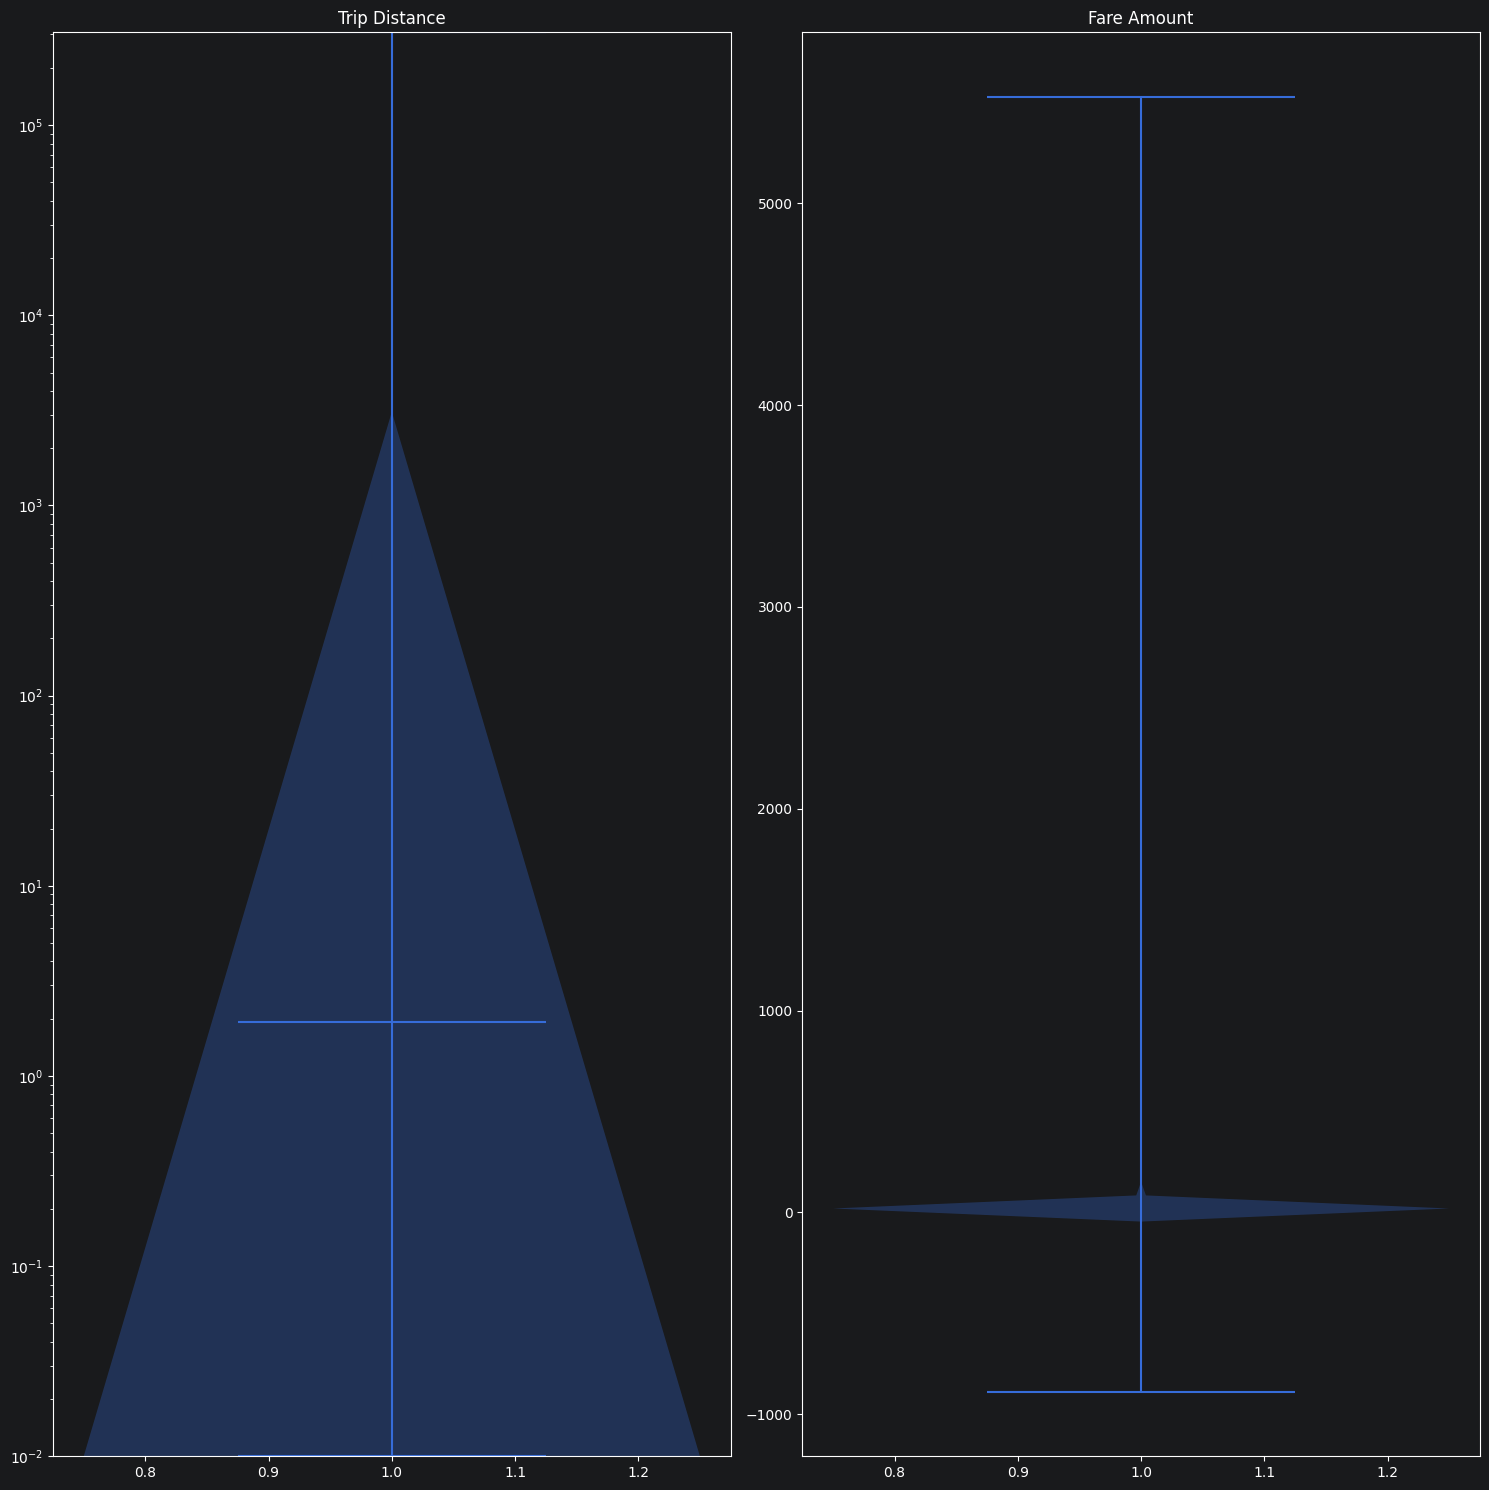

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 15))

axs[0].set_title("Trip Distance")
axs[0].violinplot(df_main["trip_distance"], orientation="vertical", showmeans=False, showmedians=True)
axs[0].set_yscale("log")
axs[0].set_ylim(df_main["trip_distance"].min(), df_main["trip_distance"].max())

#plot fare amount
axs[1].set_title("Fare Amount")
axs[1].violinplot(df_main["fare_amount"], orientation="vertical")

plt.tight_layout()
plt.show()